In [1]:

%load_ext autoreload
%autoreload 2
import os
import matplotlib.pyplot as plt
import numpy as np
import casadi as ca
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent)) 
from commom_utils.ode_system import ODESystem
from mpc.params import CarParams, MpcParams
from mpc.mpc_base_interface import MpcCogeGenerator, KinematicMpcCodegenerator, MpcModel
from mpc.mpc_control_utils import LateralMPCController, Controller, LateralPIDController, reset_solver_initial_guess
from mpc.mpc_sim_utils import SimulationPlotter, Simulator, SinusoidalCurveScenario, TrajectoryTimeProfile

In [ ]:
max_road_wheel_angle = 440.0 # deg
max_steering_wheel_angle_rate = 350.0 # deg/s
steering_gear_ratio  = 14

u_max = 1.619381290366759  #max_road_wheel_angle * np.pi / 180.0
ts = 0.02
mpc_horizont = 50
du_max =  57.814031472312166  #max_steering_wheel_angle_rate * np.pi / (180 * ts ) 
r_dist = 100.0
r_ang = 1.0
n_delay = 0
r_u = 0.2
r_du = 20.0
r_ddu = 1
r_jerk = 2
a_comf = 1.5
jerk_max = 5.0
jerk_comf = 2.0
wheel_base = 2.65
ddu_max = 1
r_dist = (r_dist/ wheel_base)
r_ang = (np.rad2deg(r_ang) / wheel_base)
r_w = 3



car_params = CarParams(
    gear_ratio=steering_gear_ratio,
    wheelbase=wheel_base,
    length=1.0,
    rear_overhang=1.0,
    u_max=u_max,
    du_max=du_max,
    ddu_max=ddu_max
)

params = MpcParams(
    car_params=car_params,
    use_dynamic_model=False,
    use_ddu_control=1,
    mpc_horizont=mpc_horizont,
    n_delay=n_delay,
    ts=ts,
    r_dist=r_dist,
    r_ang=r_ang,
    r_w=r_w,
    r_u=r_u,
    r_du=r_du,
    r_ddu=r_ddu,
    r_jerk=r_jerk,
    jerk_comf=jerk_comf,
    jerk_max=jerk_max,
    a_comf_max=5,
    final_cost=10.0
)
params.print()
code_generator  = KinematicMpcCodegenerator(params, Path(os.getcwd())/'tmp_generated', 'kinematik_mpc')
solver = code_generator.generate_code()

MpcParams:
  car_params:
    wheelbase: 2.65
    gear_ratio: 14
    length: 1.0
    rear_overhang: 1.0
    u_max: 1.619381290366759
    du_max: 57.814031472312166
    ddu_max: 1
  use_dynamic_model: False
  use_ddu_control: 1
  mpc_horizont: 50
  n_delay: 0
  ts: 0.02
  r_dist: 37.735849056603776
  r_ang: 21.621048872861255
  r_w: 3
  r_u: 0.2
  r_du: 20.0
  r_ddu: 1
  r_jerk: 2
  jerk_comf: 2.0
  jerk_max: 5.0
  a_comf_max: 5
  final_cost: 10.0
Please export ACADOS_SOURCE_DIR to avoid this warning.
con_h_expr size: 2
lh size: 2
uh size: 2
discrete:  False

got cost_type EXTERNAL for cost_type_0, cost_type, cost_type_e, hessian_approx: 'GAUSS_NEWTON'.
With this setting, acados will proceed computing the exact Hessian for the cost term and no Hessian contribution from constraints and dynamics.
If the external cost is a linear least squares cost, this coincides with the Gauss-Newton Hessian.
Note: There is also the option to use the external cost module with a numerical Hessian approxima

In [3]:
class KinematicBycicleErrors(ODESystem):
    def __init__(self, wheelbase):
        self.wheelbase = wheelbase
        super().__init__(nx=2, nu=1, np=2)
        
    def get_derivative(self, state, params, input_signals):
        d = state[0]
        psi = state[1]
        rwa = input_signals[0]
        vx = params[0]
        c = params[1]
        dd = vx * ca.sin(psi)
        dpsi = vx * ca.tan(rwa) / self.wheelbase - vx * c * ca.cos(psi) / (1 - c * d)
        return ca.vertcat(dd, dpsi)
    


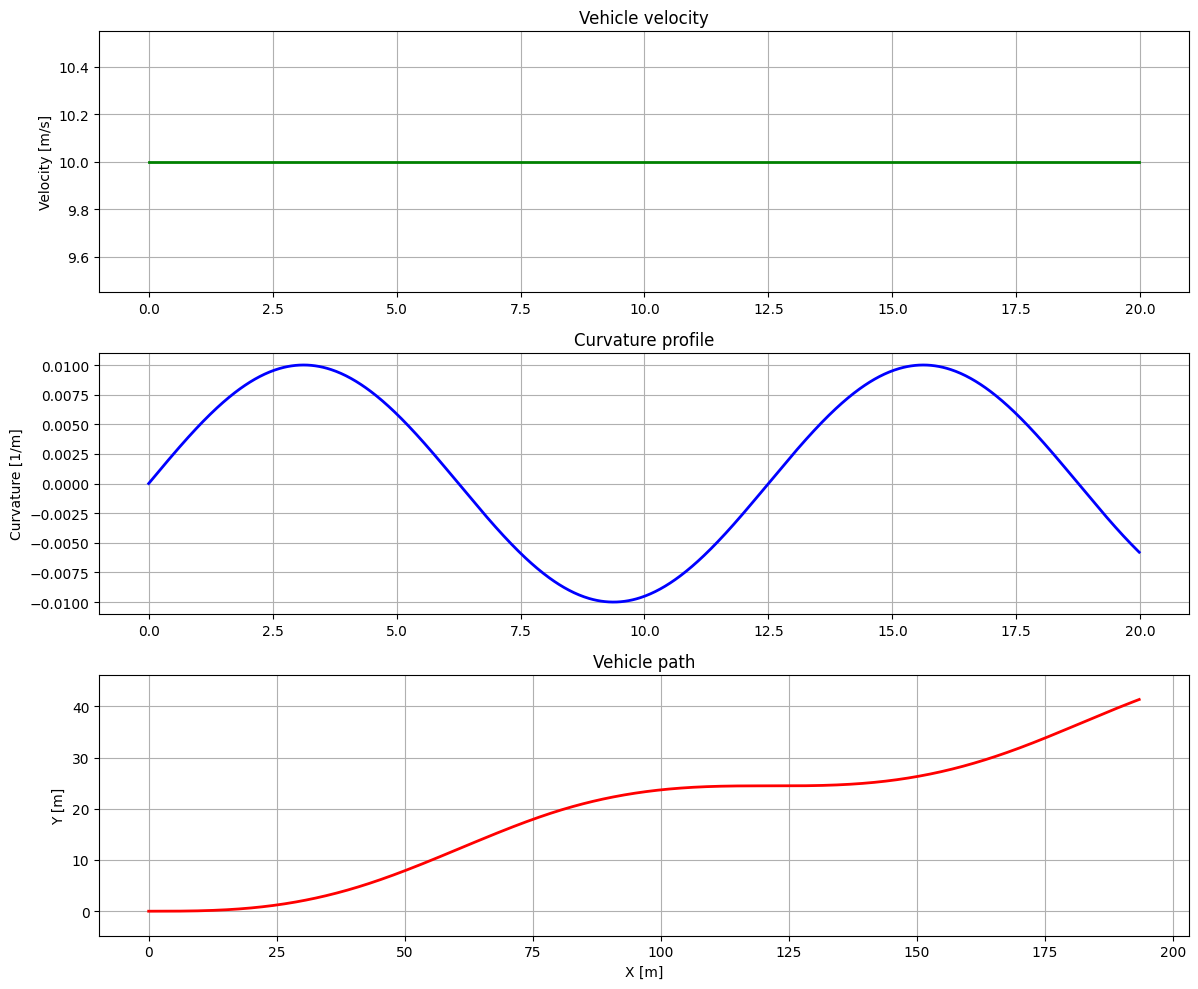

In [4]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

def reconstruct_path(trajectory, t_list, theta0=0.0, x0=0.0, y0=0.0):
    """Возвращает x, y, theta интегрированием v(t) и κ(t)."""
    def ode(t, state):
        x, y, theta = state
        v = trajectory.vel_profile(t)
        curv = trajectory.curv_profile(t)
        return [v * np.cos(theta), v * np.sin(theta), v * curv]

    sol = solve_ivp(ode, (t_list[0], t_list[-1]), [x0, y0, theta0],
                    t_eval=t_list, method='RK45')
    return sol.y[0], sol.y[1], sol.y[2]




# Выбор сценария
scenario = SinusoidalCurveScenario(velocity=10.0, curv_amplitude=0.01, frequency=0.08)

# Создание временной сетки
dt = 0.02
t_list = np.arange(0, 20, dt)

# Получение готового профиля
trajectory = scenario.create_trajectory(t_list)


# Временная сетка
t_list = np.arange(0, 20, 0.02)
x, y, theta = reconstruct_path(trajectory, t_list)

# Три графика
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 10))

# 1) Скорость
ax1.plot(t_list, trajectory.vel_profile(t_list), 'g-', linewidth=2)
ax1.set_ylabel('Velocity [m/s]')
ax1.set_title('Vehicle velocity')
ax1.grid(True)

# 2) Кривизна
ax2.plot(t_list, trajectory.curv_profile(t_list), 'b-', linewidth=2)
ax2.set_ylabel('Curvature [1/m]')
ax2.set_title('Curvature profile')
ax2.grid(True)

# 3) Путь (x, y)
ax3.plot(x, y, 'r-', linewidth=2)
ax3.set_xlabel('X [m]')
ax3.set_ylabel('Y [m]')
ax3.set_title('Vehicle path')
ax3.axis('equal')
ax3.grid(True)

plt.tight_layout()
plt.show()

In [5]:
real_model = KinematicBycicleErrors(wheelbase = 2.65)
controller = LateralPIDController(K_fb=np.array([0.2, 0.2, 0.0]), wheelbase = 2.65, yaw_rate_compensation=False)
reset_solver_initial_guess(solver)
controller = LateralMPCController(solver, trajectory)


In [6]:
sim = Simulator(real_model, controller, trajectory, 11, True)
states, controls  = sim.run(t_list, x0 = np.array([0.1, 0.02]))

[0.01 0.02 0.   0.   0.   0.  ]
  # it     res_stat       res_eq     res_ineq     res_comp   qp_stat   qp_iter  step_norm    lm_reg.     alpha   
     0   2.0051e-05   9.4584e-04   2.0000e-02   0.0000e+00         0         0   0.00e+00   0.00e+00  1.00e+00    
     1   5.9707e+00   1.0193e-07   0.0000e+00   2.9791e-13         0         6   1.00e+00   0.00e+00  1.00e+00    
     2   3.1793e-01   2.7292e-09   0.0000e+00   1.6851e-07         0         4   6.03e-01   0.00e+00  1.00e+00    
     3   9.0693e-02   5.7761e-12   0.0000e+00   7.2544e-08         0         4   8.94e-02   0.00e+00  1.00e+00    
     4   2.1979e-06   4.3594e-13   0.0000e+00   7.5557e-08         0         4   2.59e-02   0.00e+00  1.00e+00    
     5   9.0209e-11   2.0817e-17   0.0000e+00   7.8295e-08         0         4   1.79e-07   0.00e+00  1.00e+00    
Optimal solution found! Converged to KKT point.
[ 1.03999734e-02  1.99999996e-02 -1.99999977e-04 -1.99999977e-02
 -1.99999977e-06 -3.39999961e-04]
  # it     res_st

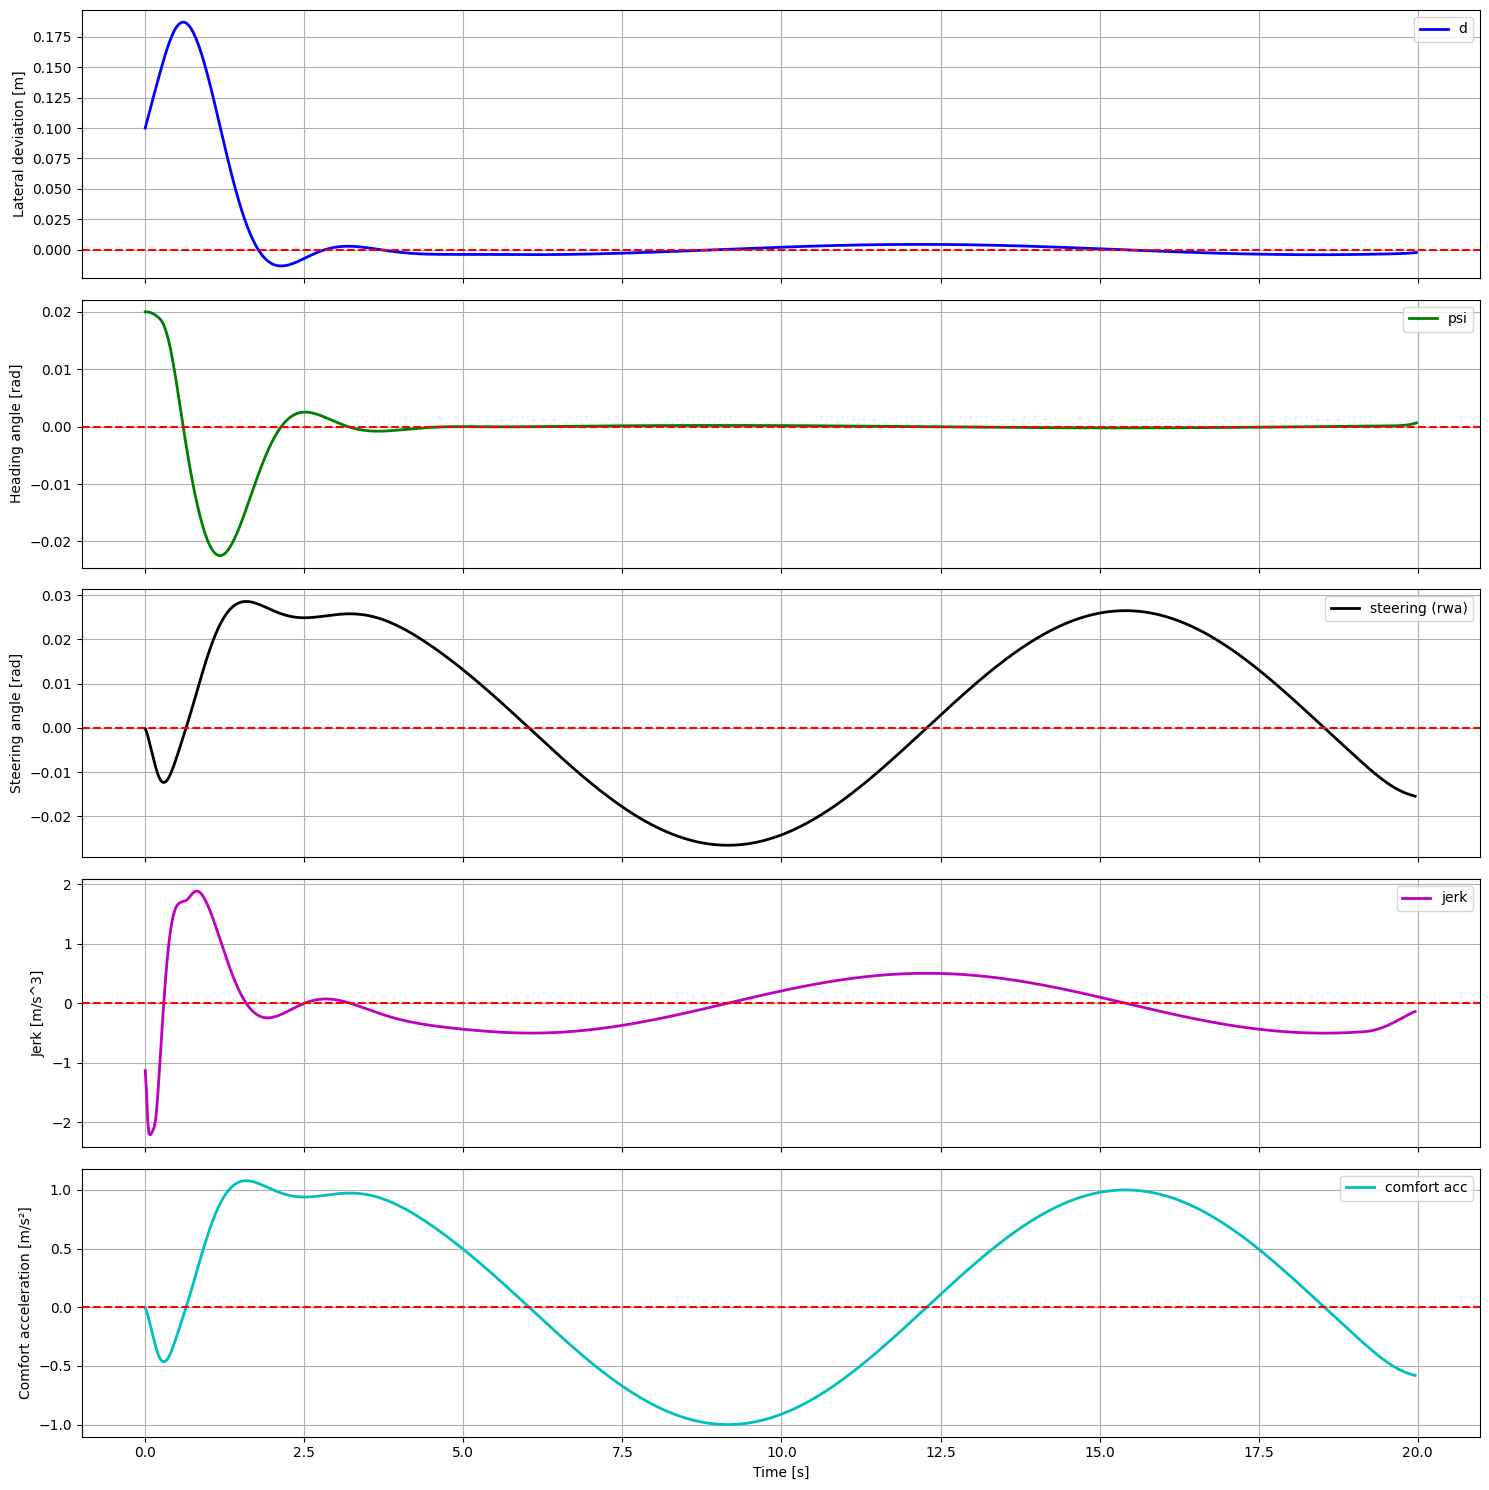

In [7]:
plotter = SimulationPlotter(t_list, states, controls, trajectory=trajectory, model=real_model)
fig, axs = plotter.plot_all(include_jerk=True, include_comfort=True)
plt.show()
